# Module 3 — Solution thermodynamics, and the constraint that makes a model a model

**2105603 Advanced Chemical Engineering Thermodynamics**
Department of Chemical Engineering, Chulalongkorn University
Soorathep Kheawhom

---

Mix one litre of ethanol with one litre of water and you get 1.93 litres. The
68 cm³ that went missing is the whole of this module: a property of a mixture
is not the sum of the properties of what went into it, and the bookkeeping that
repairs that is the partial molar property.

This notebook builds the mixture toolkit with the rigour Module 1 applied to
pure fluids:

| step | question |
|---|---|
| 1 | what is a partial molar property, and does the Euler relation really close? |
| 2 | why can a partial molar volume be negative, and what does that mean? |
| 3 | what constraint links $\gamma_1$ and $\gamma_2$, and what does violating it cost? |
| 4 | $G^E = H^E - TS^E$: which term is actually carrying the non-ideality? |
| 5 | two reference states, one dataset — why two papers can disagree by a factor |
| 6 | four models on one dataset: where they agree, and where they do not |

**Rule for this notebook, as for Modules 4 and 5.** Every number reported here
is reproduced by an independent route, and every number that came out of a
model rather than a measurement says so. Section 3 is the heart of the module:
an activity coefficient model is a **choice of excess Gibbs energy**, not an
item on a list to memorise, and the reason is a constraint you can measure the
violation of.

## 0. Setup

In [1]:
import sys, subprocess, importlib, importlib.util, os

def ensure(pkg, pipname=None):
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        pipname or pkg], check=False)

for p in ("numpy", "scipy", "matplotlib"):
    ensure(p)
ensure("thermo")          # Sections 1 and 4 use it

if not os.path.isdir("vlekit") and importlib.util.find_spec("vlekit") is None:
    import urllib.request, zipfile, io
    URL = "https://www.skhgroup.net/teaching/2105603/files/vlekit.zip"
    try:
        with urllib.request.urlopen(URL, timeout=30) as r:
            zipfile.ZipFile(io.BytesIO(r.read())).extractall(".")
        print("downloaded vlekit from the course page")
    except Exception as e:
        print("could not download vlekit:", e)

import numpy as np
import matplotlib.pyplot as plt
import vlekit as v
from vlekit import models as M, unifac as U, plots as pl

pl.use_style()
R = 8.314462618          # J/mol/K
print("vlekit", v.__version__)

vlekit 0.1.0


## 1. The tangent-intercept construction, done numerically

$$\bar M_i \equiv \left(\frac{\partial (nM)}{\partial n_i}\right)_{T,P,n_{j\ne i}}
\qquad\qquad
\bar M_1 = M + x_2\frac{{\rm d}M}{{\rm d}x_1}
\qquad
\bar M_2 = M - x_1\frac{{\rm d}M}{{\rm d}x_1}$$

The second pair is the tangent construction: draw the tangent to $M(x_1)$ at
one composition, and its intercepts at $x_1 = 0$ and $x_1 = 1$ **are** the two
partial molar properties there.

### The data, and where it came from

Volume is the one partial molar property you can see in a measuring cylinder,
so the property here is the molar volume of **ethanol (1) + water (2) at
298.15 K**. Three ingredients, and they are not of equal standing — read this
before you use any number from this section.

* **the curve — verified.** $V^E$ from the Redlich-Kister correlation of
  Danahy, Minnick & Shiflett, *Fermentation* **2018**, 4(3), 72, open access
  under CC-BY, doi:10.3390/fermentation4030072. The paper was retrieved and the
  citation checked: the correlation is a second-order temperature-dependent
  Redlich-Kister expansion regressed on published experimental densities, valid
  over 283.15–313.15 K and 0–100 wt % ethanol, with an average absolute
  relative deviation of 0.09 % in density. It is a **correlation of
  measurements**, not raw data — which matters in Section 2, where it gets
  differentiated at the composition endpoints.

* **the pure molar volumes — verified, and computed at run time.** $V_1$ and
  $V_2$ come from `thermo`'s `VolumeLiquid` `HEOS_FIT` correlations, which are
  fits to the reference multiparameter equations of state for ethanol and
  water. Nothing is typed in, and the values are cross-checked below against
  the unrelated `vL` entries in `vlekit.data.LIBRARY`.

* **the circles — NOT verified.** Eleven $(x_1,\rho)$ pairs attributed to
  Pawar & Aher, *IJSRSET* **2017**, 3(6), 432–447, Table 2. **This source could
  not be independently verified.** The journal is not indexed in the citation
  databases available here, the article carries no DOI, and neither the article
  nor its Table 2 could be retrieved to confirm that these eleven numbers are
  what it reports. They are therefore **not** offered as an independent
  measured dataset. They are a transcription of unknown provenance, shown as a
  visual sanity check and nothing more. The one honest statement available
  about them is the one computed below — they agree with the verified
  correlation to about 0.05 cm³/mol — and that is *consistent* with their being
  real pycnometric data, not *evidence* that they are. **Do not cite them, and
  do not reuse them in your own work.**

**Nothing in Sections 1 and 2 depends on the unverified points.** Every number
reported — the tangent intercepts, the Euler residuals, the infinite-dilution
partial molar volumes, the 1 L + 1 L contraction — comes from the correlation
and the run-time pure volumes. Delete the eleven pairs and only the circles on
the figure disappear.

In [2]:
T1 = 298.15

# ---- VERIFIED: pure molar volumes, computed at run time ---------------------
from chemicals import MW
from thermo.volume import VolumeLiquid

CAS1, CAS2 = "64-17-5", "7732-18-5"           # ethanol, water
M1, M2 = float(MW(CAS1)), float(MW(CAS2))     # g/mol
V1 = float(VolumeLiquid(CASRN=CAS1).calculate(T1, "HEOS_FIT")) * 1e6
V2 = float(VolumeLiquid(CASRN=CAS2).calculate(T1, "HEOS_FIT")) * 1e6

# ---- VERIFIED: Danahy et al. (2018) Table 1, CC-BY --------------------------
# V^E = x1 x2 [A + B(1-2x1) + C(1-2x1)^2],  A = a0 + a1 T, etc., cm^3/mol
A_RK = -9.054199 + 0.01572057 * T1
B_RK = -4.930763 + 0.01241796 * T1
C_RK = 5.286817 - 0.01989784 * T1

# ---- NOT VERIFIED: see the markdown above before using these ----------------
# Eleven (x1, density / g cm^-3) pairs attributed to Pawar & Aher, IJSRSET
# 2017, 3(6), 432-447, Table 2. The source could not be retrieved or confirmed.
# Plotted as a sanity check only; no number in this notebook depends on them.
UNVERIFIED_DENSITIES = np.array([
    [0.0000, 0.9970], [0.0719, 0.9706], [0.1483, 0.9490], [0.2300, 0.9249],
    [0.3168, 0.9005], [0.4104, 0.8779], [0.5089, 0.8572], [0.6187, 0.8383],
    [0.7358, 0.8202], [0.8622, 0.8038], [1.0000, 0.7861]])

def VE(x1):
    """Excess molar volume, cm^3/mol. Danahy correlation."""
    x1 = np.asarray(x1, float)
    z = 1 - 2 * x1
    return x1 * (1 - x1) * (A_RK + B_RK * z + C_RK * z ** 2)

def V(x1):
    """Molar volume of the mixture, cm^3/mol."""
    x1 = np.asarray(x1, float)
    return x1 * V1 + (1 - x1) * V2 + VE(x1)

print("pure molar volumes from thermo HEOS_FIT (reference equations of state):")
print(f"  ethanol V1 = {V1:.4f} cm3/mol   (vlekit LIBRARY vL "
      f"{v.component('ethanol').vL * 1e6:.2f})")
print(f"  water   V2 = {V2:.4f} cm3/mol   (vlekit LIBRARY vL "
      f"{v.component('water').vL * 1e6:.2f})")
print(f"deepest excess volume: {VE(np.linspace(0,1,1001)).min():.4f} cm3/mol")

xp, rho = UNVERIFIED_DENSITIES[:, 0], UNVERIFIED_DENSITIES[:, 1]
Vp = (xp * M1 + (1 - xp) * M2) / rho
VEp = Vp - (xp * V1 + (1 - xp) * V2)
print("\n*** the eleven circles are an UNVERIFIED transcription (see above) ***")
print(f"    they track the verified correlation to rms "
      f"{np.sqrt(np.mean((VEp - VE(xp))**2)):.4f} cm3/mol, max "
      f"{np.max(np.abs(VEp - VE(xp))):.4f} cm3/mol")
print(f"    their implied pure volumes: ethanol {M1/rho[-1]:.4f}, water "
      f"{M2/rho[0]:.4f} cm3/mol  (vs {V1:.4f}, {V2:.4f} above)")
print("    consistent with real data; NOT evidence of provenance.")

pure molar volumes from thermo HEOS_FIT (reference equations of state):
  ethanol V1 = 58.6760 cm3/mol   (vlekit LIBRARY vL 58.70)
  water   V2 = 18.0686 cm3/mol   (vlekit LIBRARY vL 18.07)
deepest excess volume: -1.1158 cm3/mol

*** the eleven circles are an UNVERIFIED transcription (see above) ***
    they track the verified correlation to rms 0.0504 cm3/mol, max 0.1229 cm3/mol
    their implied pure volumes: ethanol 58.6038, water 18.0695 cm3/mol  (vs 58.6760, 18.0686 above)
    consistent with real data; NOT evidence of provenance.


### The opening number

One litre of each, mixed. Everything below comes from the two functions above.

In [3]:
n1, n2 = 1000.0 / V1, 1000.0 / V2             # moles in 1 L of each pure liquid
n = n1 + n2
x_mix = n1 / n
Vtot = n * float(V(x_mix))
print(f"1 L ethanol = {n1:.3f} mol,  1 L water = {n2:.3f} mol,  "
      f"x1 = {x_mix:.4f}")
print(f"total volume = {Vtot:.1f} cm3 = {Vtot/1000:.3f} L,  not 2.000 L")
print(f"contraction  = {2000 - Vtot:.1f} cm3  "
      f"(= n V^E = {-n * float(VE(x_mix)):.1f} cm3)")

1 L ethanol = 17.043 mol,  1 L water = 55.345 mol,  x1 = 0.2354
total volume = 1932.3 cm3 = 1.932 L,  not 2.000 L
contraction  = 67.7 cm3  (= n V^E = 67.7 cm3)


### Two routes to $\bar V_i$, and the Euler relation

Route A is the tangent construction. Route B goes back to the definition and
differentiates $nV(n_1,n_2)$ with respect to a **mole number**, which is a
different calculation in floating point even though it is the same quantity in
algebra. Then the Euler relation $V = x_1\bar V_1 + x_2\bar V_2$ is checked.

In [4]:
x = np.linspace(1e-4, 1 - 1e-4, 999)
h = 1e-6

# --- route A: tangent intercepts
dVdx = (V(x + h) - V(x - h)) / (2 * h)
Vb1_A = V(x) + (1 - x) * dVdx
Vb2_A = V(x) - x * dVdx

# --- route B: derivative with respect to mole number, at n = 1
def nV(n1, n2):
    nt = n1 + n2
    return nt * V(n1 / nt)

Vb1_B = (nV(x + h, 1 - x) - nV(x - h, 1 - x)) / (2 * h)
Vb2_B = (nV(x, 1 - x + h) - nV(x, 1 - x - h)) / (2 * h)

print(f"max |tangent - mole-number| :  V1bar {np.max(np.abs(Vb1_A-Vb1_B)):.2e}"
      f"   V2bar {np.max(np.abs(Vb2_A-Vb2_B)):.2e}  cm3/mol")

# --- the Euler relation, from each route
euler_A = np.max(np.abs(x * Vb1_A + (1 - x) * Vb2_A - V(x)))
euler_B = np.max(np.abs(x * Vb1_B + (1 - x) * Vb2_B - V(x)))
print(f"\nEuler residual, route A (tangent)      : {euler_A:.3e} cm3/mol")
print(f"Euler residual, route B (mole numbers) : {euler_B:.3e} cm3/mol")

max |tangent - mole-number| :  V1bar 1.06e-08   V2bar 1.28e-08  cm3/mol

Euler residual, route A (tangent)      : 7.105e-15 cm3/mol
Euler residual, route B (mole numbers) : 8.959e-09 cm3/mol


**Read those two residuals differently.**

Route A returns the input to about $7\times10^{-15}$ cm³/mol — a few floating
point ulps on a number of order 30. That is *not* a numerical triumph: substitute
the two tangent formulae into $x_1\bar V_1 + x_2\bar V_2$ and the derivative
term cancels **algebraically**, whatever $V(x_1)$ is. Route A therefore tests
arithmetic, not thermodynamics.

Route B is the honest check. It differentiates $nV$ with respect to $n_1$ and
$n_2$ separately, and the two derivatives know nothing about each other. It
reproduces route A to about $10^{-8}$ cm³/mol — the accuracy of a central
difference with $h = 10^{-6}$, not of the theory — and its Euler residual is
the same size. **The Euler relation closing is a property of $nM$ being
homogeneous of degree one in the mole numbers**, and route B is where you see
that being used.

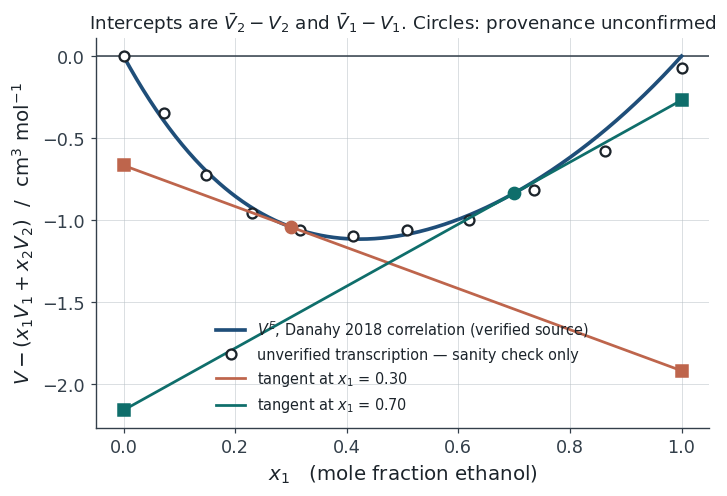

In [5]:
xs = np.linspace(0, 1, 601)
xt = (0.30, 0.70)                       # the two tangent points

fig, ax = pl.newfig(7.2, 4.6)
ax.axhline(0.0, color=pl.GRAPHITE, lw=1.0)
ax.plot(xs, VE(xs), "-", color=pl.NAVY, lw=2.4,
        label="$V^E$, Danahy 2018 correlation (verified source)")
ax.plot(xp, VEp, "o", color=pl.INK, mfc="white", mew=1.5, ms=6.5,
        label="unverified transcription — sanity check only")
for xi, col in zip(xt, (pl.RUST, pl.TEAL)):
    d = float((V(xi + h) - V(xi - h)) / (2 * h))
    lo = float(V(xi)) - xi * d - V2               # intercept at x1 = 0, minus V2
    hi = float(V(xi)) + (1 - xi) * d - V1         # intercept at x1 = 1, minus V1
    ax.plot([0, 1], [lo, hi], "-", color=col, lw=1.8,
            label=f"tangent at $x_1$ = {xi:.2f}")
    ax.plot([xi], [float(VE(xi))], "o", color=col, ms=8)
    ax.plot([0, 1], [lo, hi], "s", color=col, ms=8)
ax.set_xlabel("$x_1$   (mole fraction ethanol)")
ax.set_ylabel("$V-(x_1V_1+x_2V_2)$  /  cm$^3$ mol$^{-1}$")
ax.set_title("Intercepts are $\\bar V_2-V_2$ and $\\bar V_1-V_1$. "
             "Circles: provenance unconfirmed", fontsize=12)
ax.legend(loc="lower center", fontsize=9.5)
plt.show()

The ideal line has been subtracted, because on the raw $V$ axis the whole
effect — about 1.1 cm³/mol — is invisible against a 40 cm³/mol range. That is a
general lesson about plotting a small departure from a large trend, and it is
the reason so many published mixture-volume figures show nothing.

The curve and the tangents are the figure. The circles are on it only so that
a reader can see the shape is not an artefact of one correlation — and, as
Section 1's data note says, their provenance could not be confirmed, so they
carry no weight in anything claimed here.

**Question 1.1.** What would the tangent look like for an ideal solution, and
what would the two intercepts be?

**Question 1.2.** Change `h` in the mole-number route from $10^{-6}$ to
$10^{-2}$ and to $10^{-10}$, and re-run. Explain the two ways it gets worse.

**Question 1.3.** Route A cannot fail. Construct a $V(x_1)$ that is *not* a
physically sensible molar volume — say $V = 1/x_1$ — and confirm that route A
still closes the Euler relation exactly. What does that tell you about using
the Euler relation as a check on your data?

## 2. A partial molar volume can be negative

$\bar V_i$ is a **marginal** quantity: the volume the solution gains when one
mole of $i$ is added to so much solution that the composition does not move. It
is not "the volume the molecules of $i$ occupy", and the clearest way to see
that is a case where it goes negative.

Start with what the verified correlation gives.

In [6]:
x = np.linspace(1e-4, 1 - 1e-4, 999)
dVdx = (V(x + h) - V(x - h)) / (2 * h)
Vb1 = V(x) + (1 - x) * dVdx           # ethanol
Vb2 = V(x) - x * dVdx                 # water

print(f"pure                   V1 = {V1:7.3f}    V2 = {V2:7.3f}  cm3/mol")
print(f"at infinite dilution   V1 = {Vb1[0]:7.3f}    V2 = {Vb2[-1]:7.3f}  "
      f"cm3/mol")
print(f"                     {100*(Vb1[0]-V1)/V1:+7.1f} %  "
      f"{100*(Vb2[-1]-V2)/V2:+7.1f} %  relative to pure")
print(f"\nrange over the whole composition:  "
      f"V1bar {Vb1.min():.2f} to {Vb1.max():.2f},  "
      f"V2bar {Vb2.min():.2f} to {Vb2.max():.2f}")

# How much do those two endpoint values depend on the SHAPE of the fit rather
# than on the data behind it? Refit the same curve with the C term dropped.
Dm = np.vstack([x * (1 - x), x * (1 - x) * (1 - 2 * x)]).T
p2, *_ = np.linalg.lstsq(Dm, VE(x), rcond=None)
VE_2t = lambda t: (np.asarray(t, float) * (1 - np.asarray(t, float))
                 * (p2[0] + p2[1] * (1 - 2 * np.asarray(t, float))))
V_2t = lambda t: np.asarray(t, float) * V1 + (1 - np.asarray(t, float)) * V2 + VE_2t(t)
d_2t = (V_2t(x + h) - V_2t(x - h)) / (2 * h)
print(f"\ndrop the C term and refit the SAME curve:")
print(f"   the V^E curve moves by only "
      f"{np.sqrt(np.mean((VE_2t(x)-VE(x))**2)):.4f} cm3/mol rms,")
print(f"   but V1bar(inf) moves {(V_2t(x)+(1-x)*d_2t)[0]-Vb1[0]:+.3f} and "
      f"V2bar(inf) moves {(V_2t(x)-x*d_2t)[-1]-Vb2[-1]:+.3f} cm3/mol.")
print("   endpoint derivatives are far less determined than the fit looks.")

pure                   V1 =  58.676    V2 =  18.069  cm3/mol
at infinite dilution   V1 =  52.437    V2 =  14.285  cm3/mol
                       -10.6 %    -20.9 %  relative to pure

range over the whole composition:  V1bar 52.44 to 58.68,  V2bar 14.28 to 18.07

drop the C term and refit the SAME curve:
   the V^E curve moves by only 0.0194 cm3/mol rms,
   but V1bar(inf) moves +0.553 and V2bar(inf) moves +0.553 cm3/mol.
   endpoint derivatives are far less determined than the fit looks.


A mole of water added to nearly pure ethanol takes up 14.28 cm³, not
18.07 — 21 % less than a mole of water occupies on its own. A mole of ethanol
added to nearly pure water takes up about 11 % less than pure ethanol. Water's
hydrogen-bonded network has voids, and a solute that can sit in them adds less
volume than it owns.

Neither number is negative, and — this matters — neither is a measurement.
Both are **endpoint derivatives of a fitted correlation**. The correlation's
stated validity does cover the whole composition range, so this is not
extrapolation beyond its range; the weakness is subtler. A fit regressed to
reproduce *density* to 0.09 % is not thereby guaranteed to reproduce
${\rm d}V/{\rm d}x_1$ at the ends, and the cell above measures exactly that:
dropping the third Redlich-Kister term changes the $V^E$ curve by 0.019 cm³/mol
rms — invisible on any plot — and moves **both** infinite-dilution values by
0.55 cm³/mol. Quote $\bar V_i^\infty$ to a fraction of a cm³/mol, not to the
four figures printed, and say which correlation you differentiated.

**How much contraction would it take to go negative?** Scale the correlated
excess volume by a factor $k$ and find where $\bar V_2$ first crosses zero. The
scaled curve is **synthetic** — it is not any real mixture — and it is used
only to answer the question "how strong must the effect be?".

In [7]:
from scipy.optimize import brentq

def min_Vbar2(k):
    """Minimum partial molar volume of water when V^E is scaled by k."""
    Vk = lambda z: z * V1 + (1 - z) * V2 + k * VE(z)
    d = (Vk(x + h) - Vk(x - h)) / (2 * h)
    return float((Vk(x) - x * d).min())

k_star = brentq(min_Vbar2, 1.0, 10.0, xtol=1e-8)
print(f"V2bar first reaches zero at k = {k_star:.3f}")
print(f"   correlation deepest V^E : {VE(x).min():.3f} cm3/mol")
print(f"   scaled      deepest V^E : {k_star*VE(x).min():.3f} cm3/mol  "
      f"<- SYNTHETIC, not a real mixture")

k_show = 6.0
Vk = lambda z: z * V1 + (1 - z) * V2 + k_show * VE(z)
dk = (Vk(x + h) - Vk(x - h)) / (2 * h)
Vb2k = Vk(x) - x * dk
print(f"\nat k = {k_show:.0f} the synthetic V2bar reaches "
      f"{Vb2k.min():.2f} cm3/mol at x1 = {x[Vb2k.argmin()]:.3f}: negative.")

V2bar first reaches zero at k = 4.775
   correlation deepest V^E : -1.116 cm3/mol
   scaled      deepest V^E : -5.328 cm3/mol  <- SYNTHETIC, not a real mixture

at k = 6 the synthetic V2bar reaches -4.63 cm3/mol at x1 = 1.000: negative.


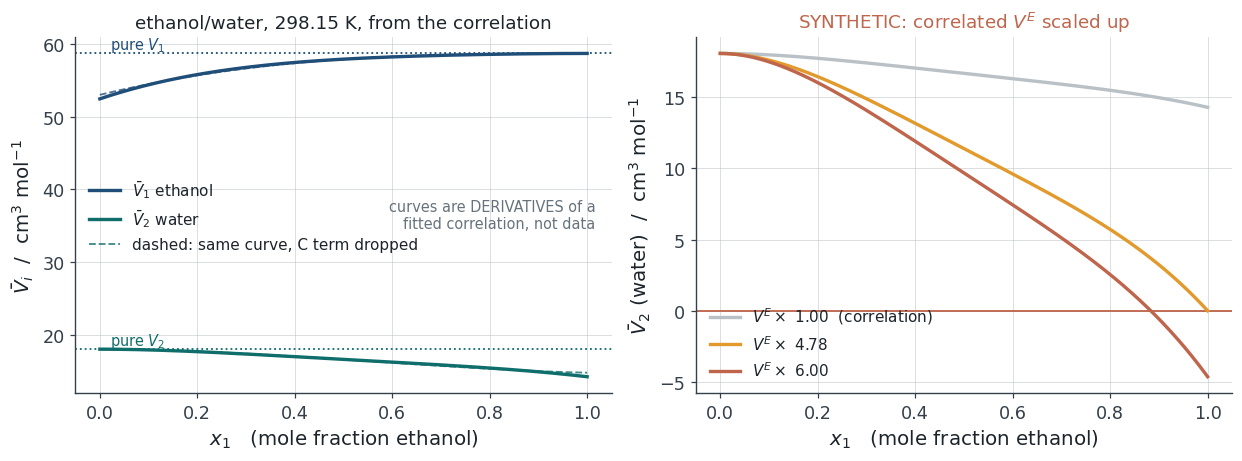

In [8]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
for a in (a1, a2):
    a.grid(True, zorder=0); a.set_axisbelow(True)

# ---- left: differentiated from the verified correlation
a1.plot(x, Vb1, "-", color=pl.NAVY, lw=2.2, label=r"$\bar V_1$ ethanol")
a1.plot(x, Vb2, "-", color=pl.TEAL, lw=2.2, label=r"$\bar V_2$ water")
a1.plot(x, (V_2t(x) + (1 - x) * d_2t), "--", color=pl.NAVY, lw=1.2, alpha=0.8)
a1.plot(x, (V_2t(x) - x * d_2t), "--", color=pl.TEAL, lw=1.2, alpha=0.8,
        label="dashed: same curve, C term dropped")
a1.axhline(V1, color=pl.NAVY, ls=":", lw=1.2)
a1.axhline(V2, color=pl.TEAL, ls=":", lw=1.2)
a1.text(0.02, V1 + 0.6, "pure $V_1$", color=pl.NAVY, fontsize=9.5)
a1.text(0.02, V2 + 0.6, "pure $V_2$", color=pl.TEAL, fontsize=9.5)
a1.text(0.97, 0.50, "curves are DERIVATIVES of a\nfitted correlation, not data",
        transform=a1.transAxes, ha="right", va="center", fontsize=9.5,
        color=pl.SLATE)
a1.set_xlabel("$x_1$   (mole fraction ethanol)")
a1.set_ylabel(r"$\bar V_i$  /  cm$^3$ mol$^{-1}$")
a1.set_title("ethanol/water, 298.15 K, from the correlation", fontsize=12)
a1.legend(loc="center left", fontsize=10)

# ---- right: the synthetic exaggeration
a2.axhline(0.0, color=pl.RUST, lw=1.2)
for kk, col in ((1.0, pl.MIST), (k_star, pl.AMBER), (k_show, pl.RUST)):
    Vkk = lambda z, kk=kk: z * V1 + (1 - z) * V2 + kk * VE(z)
    d = (Vkk(x + h) - Vkk(x - h)) / (2 * h)
    a2.plot(x, Vkk(x) - x * d, "-", color=col, lw=2.2,
            label=f"$V^E \\times$ {kk:.2f}"
                  + ("  (correlation)" if kk == 1.0 else ""))
a2.set_xlabel("$x_1$   (mole fraction ethanol)")
a2.set_ylabel(r"$\bar V_2$ (water)  /  cm$^3$ mol$^{-1}$")
a2.set_title("SYNTHETIC: correlated $V^E$ scaled up", fontsize=12, color=pl.RUST)
a2.legend(loc="lower left", fontsize=10)
fig.tight_layout()
plt.show()

**The right-hand panel is not data.** It is the correlated excess volume
multiplied by a constant, drawn to answer one question: an excess contraction
about **4.8 times** the ethanol/water one is enough to drive $\bar V_2$
negative. Nothing about ethanol and water is being claimed there.

**Real systems reach that regime.** Small, highly charged ions in water order
and compress the surrounding solvent — *electrostriction* — and the resulting
partial molar volumes are often negative; Hirata, Imai & Irisa,
*Rev. High Pressure Sci. Technol.* **1998**, 8(2), 96–103
(doi:10.4131/jshpreview.8.96, open access) state it plainly: "the partial molar
volume of small ions in water is often negative … attributed to so-called
electrostriction". No number from that literature is used here; the
demonstration above is the computed one, and the citation is for the physics.

Physically, a negative $\bar V_i$ says: add a mole of $i$ to a large volume of
solution and the beaker level **falls**. That is impossible to reconcile with
"$\bar V_i$ is the volume of species $i$", and possible immediately once you
read $\bar V_i$ as a marginal derivative that includes what the solute does to
the solvent around it.

**Question 2.1.** $\bar V_1$ and $\bar V_2$ move in opposite directions
everywhere on the left-hand panel. Which equation forces that? (You will prove
it in Section 3.)

**Question 2.2.** The cell above dropped one Redlich-Kister term and moved
$\bar V_1^\infty$ by 0.55 cm³/mol. Compare that with the 11 % effect
(6.2 cm³/mol) the section is trying to report, and state how many significant
figures $\bar V_1^\infty$ deserves. Then find a *retrievable* source of
ethanol/water densities — one with a DOI you can resolve — and redo the whole
section on it.

## 3. Gibbs-Duhem is a test, not a decoration

Because $\mu_i$ is a partial molar property, the Gibbs-Duhem equation applies
to it, and at constant $T$ and $P$

$$\sum_i x_i\,{\rm d}\bar M_i = 0
\quad\Longrightarrow\quad
\sum_i x_i\,{\rm d}\ln\hat f_i = 0
\quad\Longrightarrow\quad
x_1 \frac{{\rm d}\ln\gamma_1}{{\rm d}x_1}
+ x_2 \frac{{\rm d}\ln\gamma_2}{{\rm d}x_1} = 0 .$$

Nothing was added at any arrow; the constraint is **inherited** from $\mu_i$
being a partial molar quantity. Its consequence is the sentence this module
exists to install:

> $\gamma_1$ and $\gamma_2$ are not independent functions of composition.
> Fitting them separately produces a pair that thermodynamics forbids.

### The reference "data"

We need $\gamma_1(x_1)$ and $\gamma_2(x_1)$ for a strongly non-ideal system.
They come from `vlekit.unifac` — original UNIFAC, a group-contribution
prediction with **nothing fitted to any measurement of this pair**. This is a
model standing in for a laboratory dataset, and it is used because it is
noise-free: every residual below is then structure, not scatter. It is not
measured data and no conclusion here is a claim about real ethanol/water.

In [9]:
c1, c2 = v.component("ethanol"), v.component("water")
T3 = 298.15
ref = U.UNIFACModel(c1, c2)                  # nothing fitted

xd = np.linspace(0.02, 0.98, 21)             # 21 "measurements"
l1d, l2d = ref.ln_gamma(xd, T3)              # ln gamma_1, ln gamma_2
gE_d = xd * l1d + (1 - xd) * l2d             # G^E/RT = sum x_i ln gamma_i

print("reference (synthetic, UNIFAC, no noise):")
print(f"  ln gamma_1 from {l1d.max():.3f} down to {l1d.min():.3f}")
print(f"  ln gamma_2 from {l2d.min():.3f} up to  {l2d.max():.3f}")
print(f"  G^E/RT peaks at {gE_d.max():.4f} near x1 = {xd[gE_d.argmax()]:.2f}")

reference (synthetic, UNIFAC, no noise):
  ln gamma_1 from 1.832 down to 0.000
  ln gamma_2 from 0.002 up to  0.934
  G^E/RT peaks at 0.3060 near x1 = 0.40


### Write the residual yourself first

Four lines, and typing them is the difference between using a criterion and
understanding it. `vlekit` has its own version — `ActivityModel.gibbs_duhem_residual`
— but do not look at it until yours runs.

In [10]:
def my_gibbs_duhem(ln_g1, ln_g2, x1, h=1e-6):
    """x1 dln(g1)/dx1 + x2 dln(g2)/dx1, from two callables. Write this first."""
    x1 = np.asarray(x1, float)
    d1 = (ln_g1(x1 + h) - ln_g1(x1 - h)) / (2 * h)
    d2 = (ln_g2(x1 + h) - ln_g2(x1 - h)) / (2 * h)
    return x1 * d1 + (1 - x1) * d2


def my_partial_molar(model, x1, h=1e-6):
    """ln gamma_i as the partial molar quantity of G^E/RT. Also yours."""
    x1 = np.asarray(x1, float)
    g = model.gE_RT(x1)
    dg = (model.gE_RT(x1 + h) - model.gE_RT(x1 - h)) / (2 * h)
    return g + (1 - x1) * dg, g - x1 * dg

### A model built from one $G^E$

Fit a single excess Gibbs energy — the three-term Redlich-Kister expansion,
which `vlekit` calls `FourSuffixMargules` — to the $G^E/RT$ column, then
*derive* both activity coefficients from it. The fit is linear in the
parameters, so no optimiser is involved.

In [11]:
z = 2 * xd - 1                                    # z = x1 - x2
Dsn = np.vstack([xd * (1 - xd) * z ** k for k in range(3)]).T
p_rk, *_ = np.linalg.lstsq(Dsn, gE_d, rcond=None)
rk = M.FourSuffixMargules(p_rk)
print("G^E/RT = x1 x2 [A + B z + C z^2],  z = x1 - x2")
print(f"  A = {p_rk[0]:+.5f}   B = {p_rk[1]:+.5f}   C = {p_rk[2]:+.5f}")

xq = np.linspace(0.02, 0.98, 97)

# 1) is ln gamma_i really the partial molar quantity of this model's G^E?
a1, a2 = rk.ln_gamma(xq)                      # the analytical expressions
n1_, n2_ = my_partial_molar(rk, xq)           # the numerical derivative
print(f"\nanalytical vs numerical partial molar : "
      f"{max(np.max(np.abs(a1-n1_)), np.max(np.abs(a2-n2_))):.3e}")
print(f"vlekit check_partial_molar            : "
      f"{rk.check_partial_molar()[0]:.3e}   passed: "
      f"{rk.check_partial_molar()[1]}")

# 2) does it satisfy Gibbs-Duhem?
res_rk = my_gibbs_duhem(lambda t: rk.ln_gamma(t)[0],
                        lambda t: rk.ln_gamma(t)[1], xq)
print(f"\nmy Gibbs-Duhem residual, max          : "
      f"{np.max(np.abs(res_rk)):.3e}")
print(f"vlekit gibbs_duhem_residual           : "
      f"{rk.gibbs_duhem_residual():.3e}")
print(f"how well it reproduces the reference  : "
      f"rms ln g1 {np.sqrt(np.mean((rk.ln_gamma(xd)[0]-l1d)**2)):.5f}, "
      f"rms ln g2 {np.sqrt(np.mean((rk.ln_gamma(xd)[1]-l2d)**2)):.5f}")

G^E/RT = x1 x2 [A + B z + C z^2],  z = x1 - x2
  A = +1.17523   B = -0.46201   C = +0.28616

analytical vs numerical partial molar : 4.453e-11
vlekit check_partial_molar            : 4.453e-11   passed: True

my Gibbs-Duhem residual, max          : 7.605e-11
vlekit gibbs_duhem_residual           : 7.605e-11
how well it reproduces the reference  : rms ln g1 0.01661, rms ln g2 0.00709


The residual is $\sim10^{-11}$, which is the accuracy of the finite difference
and not a property of the fluid. **A model derived from a single $G^E$ satisfies
Gibbs-Duhem by construction**; a non-zero result here would mean a bug in the
model class, not a discovery about ethanol and water.

### Now fit the two branches independently

This is what "fitting $\gamma_1$ and $\gamma_2$" means if you do not go through
$G^E$: two separate least-squares problems that never speak to each other. Give
them plenty of freedom — four terms each, eight parameters against the three
above — so nobody can say the comparison was rigged by underfitting.

In [12]:
K = 4
def basis(t, K=K):
    t = np.asarray(t, float)
    return np.vstack([t ** k for k in range(1, K + 1)]).T

# ln gamma_1 fitted in powers of x2, ln gamma_2 in powers of x1, so that each
# vanishes at its own pure limit (Lewis-Randall). Nothing else is imposed.
a_par, *_ = np.linalg.lstsq(basis(1 - xd), l1d, rcond=None)
b_par, *_ = np.linalg.lstsq(basis(xd), l2d, rcond=None)

L1 = lambda t: basis(1 - t) @ a_par
L2 = lambda t: basis(t) @ b_par

print(f"branch 1 coefficients: {np.round(a_par, 4)}")
print(f"branch 2 coefficients: {np.round(b_par, 4)}")
print(f"\n{'':22s}{'params':>8}{'rms ln g1':>12}{'rms ln g2':>12}"
      f"{'max |GD residual|':>20}")
row = "{:22s}{:8d}{:12.5f}{:12.5f}{:20.3e}"
print(row.format("one G^E (RK, 3 par)", 3,
                 float(np.sqrt(np.mean((rk.ln_gamma(xd)[0] - l1d) ** 2))),
                 float(np.sqrt(np.mean((rk.ln_gamma(xd)[1] - l2d) ** 2))),
                 float(np.max(np.abs(res_rk)))))
res_ind = my_gibbs_duhem(L1, L2, xq)
print(row.format("two branches (8 par)", 8,
                 float(np.sqrt(np.mean((L1(xd) - l1d) ** 2))),
                 float(np.sqrt(np.mean((L2(xd) - l2d) ** 2))),
                 float(np.max(np.abs(res_ind)))))
print(f"\nratio of the two residuals: "
      f"{np.max(np.abs(res_ind))/np.max(np.abs(res_rk)):.2e}")

branch 1 coefficients: [-0.2639  2.9911 -6.1199  5.376 ]
branch 2 coefficients: [ 0.133   3.0996 -4.7192  2.4561]

                        params   rms ln g1   rms ln g2   max |GD residual|
one G^E (RK, 3 par)          3     0.01661     0.00709           7.605e-11
two branches (8 par)         8     0.00946     0.00180           1.856e-01

ratio of the two residuals: 2.44e+09


Read the table row by row. The independent pair **fits the reference better** —
it has more parameters and it was fitted to $\ln\gamma_i$ directly — and it is
**thermodynamically impossible**. No amount of looking at the fit quality would
have told you.

There is a second, cheaper symptom you can check by eye on any published
figure. Gibbs-Duhem at $x_1 \to 1$ forces ${\rm d}\ln\gamma_1/{\rm d}x_1 \to 0$:
the curve for the *abundant* component must flatten.

In [13]:
xe = 1 - 1e-6
s_rk = float(((rk.ln_gamma(np.array([xe + h]))[0]
               - rk.ln_gamma(np.array([xe - h]))[0]) / (2 * h))[0])
s_ind = float(((L1(np.array([xe + h])) - L1(np.array([xe - h]))) / (2 * h))[0])
print(f"d ln gamma_1 / d x1 at x1 -> 1")
print(f"   one G^E      : {s_rk:+.3e}   (must be zero)")
print(f"   two branches : {s_ind:+.3e}   (= -a1 of the branch fit, "
      f"{-a_par[0]:+.4f})")

# and the demonstration from the lecture: scale ln gamma_2 alone by 10 %
res_scaled = my_gibbs_duhem(lambda t: rk.ln_gamma(t)[0],
                            lambda t: 1.10 * rk.ln_gamma(t)[1], xq)
print(f"\nscaling ln gamma_2 alone by 10 % (invisible on a plot):")
print(f"   residual goes from {np.max(np.abs(res_rk)):.2e} "
      f"to {np.max(np.abs(res_scaled)):.3f}")

d ln gamma_1 / d x1 at x1 -> 1
   one G^E      : -2.440e-06   (must be zero)
   two branches : +2.639e-01   (= -a1 of the branch fit, +0.2639)

scaling ln gamma_2 alone by 10 % (invisible on a plot):
   residual goes from 7.61e-11 to 0.076


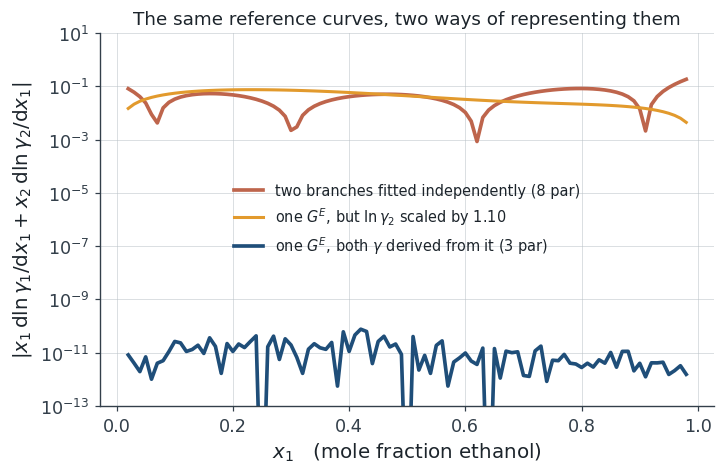

In [14]:
fig, ax = pl.newfig(7.2, 4.4)
ax.semilogy(xq, np.abs(res_ind) + 1e-18, "-", color=pl.RUST, lw=2.4,
            label="two branches fitted independently (8 par)")
ax.semilogy(xq, np.abs(res_scaled) + 1e-18, "-", color=pl.AMBER, lw=2.0,
            label=r"one $G^E$, but $\ln\gamma_2$ scaled by 1.10")
ax.semilogy(xq, np.abs(res_rk) + 1e-18, "-", color=pl.NAVY, lw=2.4,
            label="one $G^E$, both $\\gamma$ derived from it (3 par)")
ax.set_ylim(1e-13, 10)
ax.set_xlabel("$x_1$   (mole fraction ethanol)")
ax.set_ylabel(r"$|x_1\,{\rm d}\ln\gamma_1/{\rm d}x_1"
              r"+x_2\,{\rm d}\ln\gamma_2/{\rm d}x_1|$")
ax.set_title("The same reference curves, two ways of representing them",
             fontsize=12)
ax.legend(loc="center", fontsize=9.5)
plt.show()

The blue line is at the finite-difference floor. The other two are physics
violations, and the amber one — a 10 % error in one component's activity
coefficient, which no eye would catch on a $\ln\gamma$ plot — is nine orders of
magnitude above the floor. **This is why a consistency test can detect an error
a plot cannot show**, and it is the machinery Module 4 turns on real data.

**Question 3.1.** Repeat the independent fit with $K = 2$ and $K = 6$. Does more
freedom make the Gibbs-Duhem residual better or worse, and why is that the
answer you should have expected?

**Question 3.2.** The branch fits were built to vanish at their own pure limit.
Drop that constraint (add a constant term) and report what happens to the fit
quality and to the residual. Which of the two would a referee notice?

**Question 3.3.** You are handed $\gamma_1$ and $\gamma_2$ as two tables and
asked whether they are consistent. Write the check in five lines. Now say what
you would do if the tables came from an *isobaric* dataset — which term did we
drop when we wrote $\sum_i x_i\,{\rm d}\ln\gamma_i = 0$?

## 4. $G^E = H^E - TS^E$, and which term is doing the work

An excess property is measured against an ideal **solution**, not an ideal gas:

$$M^E \equiv M - M^{\,\rm id}, \qquad \frac{G^E}{RT} = \sum_i x_i\ln\gamma_i,
\qquad H^E = -RT^2\left(\frac{\partial (G^E/RT)}{\partial T}\right)_{P,x}.$$

Ethanol/water is the textbook positive-deviation system, and the naive reading
of a positive $G^E$ is that the two species dislike each other energetically.
They do not. To see that you need a $G^E$ with a **temperature dependence**,
which the models of Section 3 do not have — so this section uses modified
UNIFAC (Dortmund) through `thermo`, whose group interaction parameters are
temperature dependent and were regressed against $h^E$ data as well as VLE
(Gmehling, Li & Schiller, *Ind. Eng. Chem. Res.* **1993**, 32(1),
doi:10.1021/ie00013a024).

**Say this out loud before reading any number below: $H^E$ here is a model
derivative, not a calorimeter reading.** Differentiating a fitted correlation
with respect to temperature gives you the correlation's opinion about the
enthalpy, and the only thing checked below is that the differentiation was done
correctly.

In [15]:
from thermo.unifac import UNIFAC, DOUFIP2006, DOUFSG

CHEMGROUPS = [{1: 1, 2: 1, 14: 1}, {16: 1}]     # ethanol = CH3+CH2+OH; water

def mod_unifac(x1, T):
    return UNIFAC.from_subgroups(T=float(T), xs=[float(x1), 1 - float(x1)],
                                 chemgroups=CHEMGROUPS, version=1,
                                 interaction_data=DOUFIP2006, subgroups=DOUFSG)

def excess(x1, T):
    """G^E, H^E, T S^E in J/mol, from the model."""
    m = mod_unifac(x1, T)
    return m.GE(), m.HE(), T * m.SE()

for T in (298.15, 333.15, 348.15):
    g, hE, TsE = excess(0.50, T)
    print(f"x1 = 0.50, T = {T:.2f} K :  G^E {g:+8.2f}   H^E {hE:+8.2f}   "
          f"-T S^E {-TsE:+8.2f}  J/mol")
    print(f"                          identity G^E-(H^E-T S^E) = "
          f"{g - (hE - TsE):.2e}")

x1 = 0.50, T = 298.15 K :  G^E  +731.33   H^E  -426.24   -T S^E +1157.56  J/mol
                          identity G^E-(H^E-T S^E) = 0.00e+00
x1 = 0.50, T = 333.15 K :  G^E  +843.48   H^E    -2.01   -T S^E  +845.49  J/mol
                          identity G^E-(H^E-T S^E) = 0.00e+00
x1 = 0.50, T = 348.15 K :  G^E  +877.12   H^E  +201.75   -T S^E  +675.37  J/mol
                          identity G^E-(H^E-T S^E) = 0.00e+00


In [16]:
# check the model's analytic H^E against the definition, differentiated
# numerically. This verifies the differentiation and NOTHING else.
def hE_numeric(x1, T, dT=0.01):
    f = lambda t: mod_unifac(x1, t).GE() / (R * t)
    return -R * T ** 2 * (f(T + dT) - f(T - dT)) / (2 * dT)

worst = max(abs(excess(xx, TT)[1] - hE_numeric(xx, TT))
            for xx in (0.2, 0.5, 0.8) for TT in (298.15, 348.15))
print(f"analytic H^E vs -R T^2 d(G^E/RT)/dT :  max disagreement "
      f"{worst:.2e} J/mol")

# where does H^E change sign?
Tcross = brentq(lambda t: excess(0.50, t)[1], 300.0, 360.0, xtol=1e-6)
print(f"at x1 = 0.50, H^E crosses zero at T = {Tcross:.2f} K")
xcross = brentq(lambda xx: excess(xx, 348.15)[1], 0.05, 0.60, xtol=1e-8)
print(f"at T = 348.15 K, H^E crosses zero at x1 = {xcross:.3f} "
      f"(still negative below that)")

analytic H^E vs -R T^2 d(G^E/RT)/dT :  max disagreement 3.93e-06 J/mol
at x1 = 0.50, H^E crosses zero at T = 333.31 K
at T = 348.15 K, H^E crosses zero at x1 = 0.256 (still negative below that)


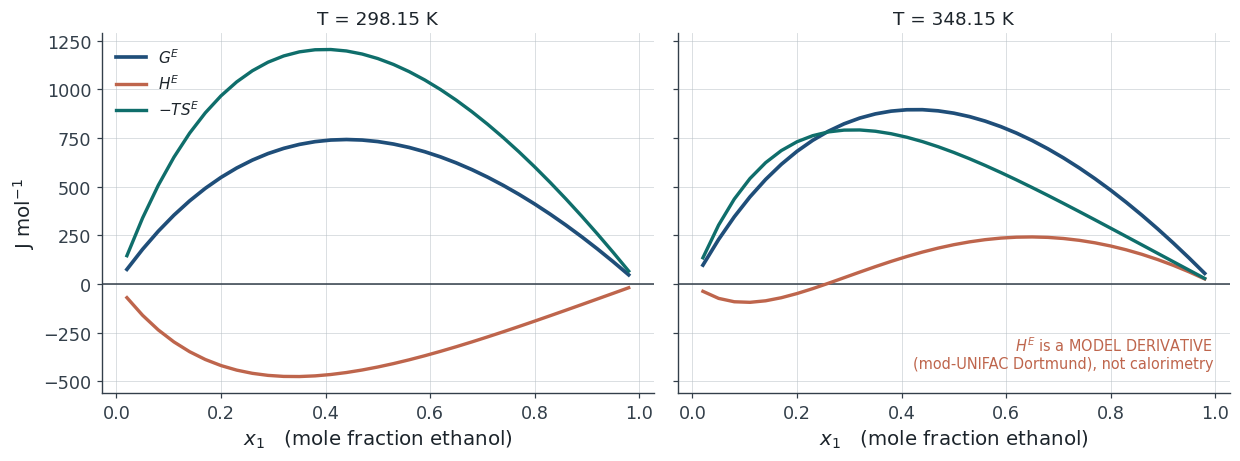

In [17]:
xg = np.linspace(0.02, 0.98, 33)
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.3), sharey=True)
for ax, T in zip(axes, (298.15, 348.15)):
    E = np.array([excess(xx, T) for xx in xg])
    ax.grid(True, zorder=0); ax.set_axisbelow(True)
    ax.axhline(0, color=pl.GRAPHITE, lw=1.0)
    ax.plot(xg, E[:, 0], "-", color=pl.NAVY, lw=2.4, label="$G^E$")
    ax.plot(xg, E[:, 1], "-", color=pl.RUST, lw=2.2, label="$H^E$")
    ax.plot(xg, -E[:, 2], "-", color=pl.TEAL, lw=2.2, label="$-TS^E$")
    ax.set_xlabel("$x_1$   (mole fraction ethanol)")
    ax.set_title(f"T = {T:.2f} K", fontsize=12)
axes[0].set_ylabel("J mol$^{-1}$")
axes[0].legend(loc="upper left", fontsize=10)
axes[1].text(0.97, 0.06, "$H^E$ is a MODEL DERIVATIVE\n(mod-UNIFAC Dortmund),"
             " not calorimetry", transform=axes[1].transAxes, ha="right",
             va="bottom", fontsize=9.5, color=pl.RUST)
fig.tight_layout()
plt.show()

**Read the balance, not the curves.** At 298.15 K and $x_1 = 0.5$ the excess
Gibbs energy is $+731$ J/mol while the excess enthalpy is $-426$ J/mol: mixing
*releases* heat, and the entire positive $G^E$ — all $+1158$ J/mol of it — is
the $-TS^E$ term. Ethanol and water are held apart by entropy, not by energy,
which is the structural signature of hydrophobic hydration. At $x_1 = 0.5$ the
enthalpy term changes sign at 333.3 K, and by 348.15 K it is $+202$ J/mol, so
both terms push $G^E$ the same way — though not everywhere: at 348.15 K, $H^E$
is still negative below $x_1 \approx 0.26$, which is why the figure is drawn
across the whole composition range and not at one point.

$G^E$ itself moves from 731 to 877 J/mol over that 50 K — 20 % — while $H^E$
swings by 628 J/mol and changes sign. **A $G^E$ model fitted at one temperature
and used at another can be right for the wrong reason**, and only a property
that depends on the temperature derivative will tell you.

The check above is worth naming for what it is: agreement to
$\sim10^{-6}$ J/mol between the model's own $H^E$ and a finite difference of its
own $G^E$ verifies the differentiation. A calorimetric $H^E$ would be a
genuinely independent test, and it is the one worth having.

**Question 4.1.** At which composition is $|H^E|$ largest at 298.15 K, and is it
the same composition where $G^E$ peaks? What does the difference tell you?

**Question 4.2.** Find the temperature at which $H^E$ changes sign at
$x_1 = 0.2$ and at $x_1 = 0.8$. Is it the same temperature? Should it be?

## 5. Two reference states, one dataset

$$a_i \equiv \frac{\hat f_i}{f_i^{\,\circ}}, \qquad
\gamma_i \equiv \frac{a_i}{x_i} = \frac{\hat f_i}{x_i f_i^{\,\circ}}$$

The activity coefficient depends on the choice of $f_i^{\,\circ}$, and that
choice is a **convention**, not a measurement:

| convention | $f_i^{\,\circ}$ | limit |
|---|---|---|
| Lewis-Randall | $f_i$, the pure liquid | $\gamma_i \to 1$ as $x_i \to 1$ |
| Henry | $\mathcal{H}_i$, the Henry constant | $\gamma_i^* \to 1$ as $x_i \to 0$ |

Same system, same fugacities, two different numbers. Two papers can report
$\gamma_1$ for the same mixture and disagree by a factor without either being
wrong. **A $\gamma$ without its convention is not a number.**

We use one dataset for both. It is generated from the same UNIFAC reference as
Section 3 (so: synthetic, noise-free, and standing in for measurements) with an
ideal vapour, which makes $\hat f_1 = y_1 P$ exactly. That assumption is checked
first.

In [18]:
dat = v.generate(ref, xd, T=T3, c1=c1, c2=c2, kind="isothermal",
                 vapour="ideal", label="UNIFAC reference (synthetic)")
print(dat, f"  P from {dat.P.min():.2f} to {dat.P.max():.2f} kPa")

# ---- is the ideal-vapour assumption defensible at these pressures?
from vlekit.data import phi_sat_virial, poynting
Tarr = np.full(dat.n, T3)
ph1, ph2 = v.phi_virial(dat.y1, Tarr, dat.P, c1, c2)
Phi1 = ph1 / phi_sat_virial(Tarr, c1) / poynting(Tarr, dat.P, c1)
Phi2 = ph2 / phi_sat_virial(Tarr, c2) / poynting(Tarr, dat.P, c2)
print(f"\nvirial + Poynting correction factor Phi_i (1.0 = ideal vapour):")
print(f"   Phi_1 in [{Phi1.min():.5f}, {Phi1.max():.5f}]")
print(f"   Phi_2 in [{Phi2.min():.5f}, {Phi2.max():.5f}]")
print("   below 8 kPa the vapour-phase correction is under 0.25 %, so"
      " f_1hat = y1 P is used from here on.")

<VLEData UNIFAC reference (synthetic) isothermal T=298.15 K, n=21>   P from 4.12 to 7.90 kPa

virial + Poynting correction factor Phi_i (1.0 = ideal vapour):
   Phi_1 in [1.00000, 1.00224]
   Phi_2 in [0.99799, 0.99963]
   below 8 kPa the vapour-phase correction is under 0.25 %, so f_1hat = y1 P is used from here on.


In [19]:
Ps1 = float(c1.Psat(T3))
f1hat = dat.y1 * dat.P                       # fugacity of ethanol in the liquid

# ---- Lewis-Randall: reference is the pure liquid, f1 = Psat1 (ideal vapour)
g_LR = f1hat / (dat.x1 * Ps1)

# ---- Henry: reference is H1 = lim_{x1->0} f1hat / x1, which must be
#      EXTRAPOLATED from data. Two routes, and they do not agree.
coef = np.polyfit(dat.x1[:5], (f1hat / dat.x1)[:5], 2)
H_data = float(np.polyval(coef, 0.0))                     # from the data
g1_inf = float(np.exp(ref.ln_gamma(np.array([1e-10]), T3)[0][0]))
H_model = g1_inf * Ps1                                    # from the model

print(f"Psat_1 (ethanol, 298.15 K)          : {Ps1:.4f} kPa")
print(f"Henry constant, quadratic on 5 lowest x : {H_data:.3f} kPa"
      f"   -> gamma_1^inf = {H_data/Ps1:.3f}")
print(f"Henry constant, from the model limit    : {H_model:.3f} kPa"
      f"   -> gamma_1^inf = {g1_inf:.3f}")
print(f"the extrapolation is off by {100*(H_data-H_model)/H_model:+.1f} % "
      f"— and the data stop at x1 = {dat.x1.min():.2f}")

g_H = f1hat / (dat.x1 * H_data)              # Henry-convention gamma*
print(f"\nmax |gamma* - gamma/gamma_1^inf| = "
      f"{np.max(np.abs(g_H - g_LR / (H_data/Ps1))):.2e}   "
      f"(the two conventions differ by exactly one division)")
print(f"\n  x1      gamma_1 (L-R)   gamma*_1 (Henry)")
for i in (0, 5, 10, 15, 20):
    print(f"{dat.x1[i]:6.2f}{g_LR[i]:15.4f}{g_H[i]:18.4f}")

Psat_1 (ethanol, 298.15 K)          : 7.8954 kPa
Henry constant, quadratic on 5 lowest x : 55.872 kPa   -> gamma_1^inf = 7.076
Henry constant, from the model limit    : 60.193 kPa   -> gamma_1^inf = 7.624
the extrapolation is off by -7.2 % — and the data stop at x1 = 0.02

max |gamma* - gamma/gamma_1^inf| = 2.22e-16   (the two conventions differ by exactly one division)

  x1      gamma_1 (L-R)   gamma*_1 (Henry)
  0.02         6.2484            0.8830
  0.26         1.7890            0.2528
  0.50         1.2037            0.1701
  0.74         1.0479            0.1481
  0.98         1.0004            0.1414


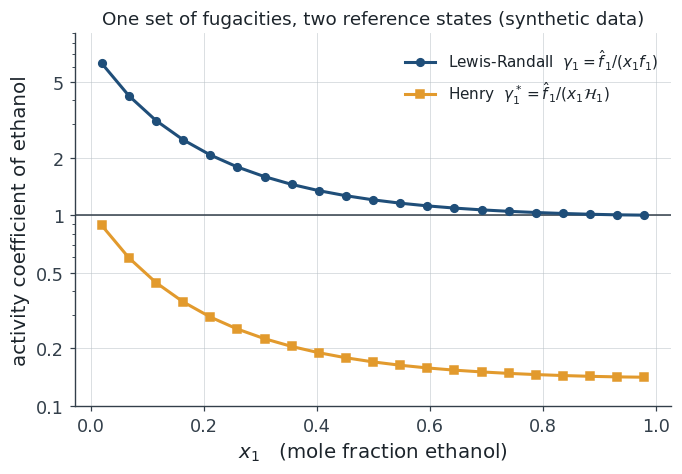

In [20]:
fig, ax = pl.newfig(7.0, 4.4)
ax.axhline(1.0, color=pl.GRAPHITE, lw=1.0)
ax.plot(dat.x1, g_LR, "o-", color=pl.NAVY, ms=5,
        label=r"Lewis-Randall  $\gamma_1=\hat f_1/(x_1 f_1)$")
ax.plot(dat.x1, g_H, "s-", color=pl.AMBER, ms=5,
        label=r"Henry  $\gamma_1^*=\hat f_1/(x_1\mathcal{H}_1)$")
ax.set_yscale("log")
ax.set_ylim(0.1, 9.0)
ax.set_yticks([0.1, 0.2, 0.5, 1.0, 2.0, 5.0])
ax.set_yticklabels(["0.1", "0.2", "0.5", "1", "2", "5"])
ax.set_xlabel("$x_1$   (mole fraction ethanol)")
ax.set_ylabel(r"activity coefficient of ethanol")
ax.set_title("One set of fugacities, two reference states "
             "(synthetic data)", fontsize=12)
ax.legend(loc="upper right", fontsize=10)
plt.show()

The two curves are the same shape shifted by a constant on a log axis — they
differ by the single factor $\gamma_1^\infty$, here about 7. Which one is
"the" activity coefficient of ethanol is not a question with an answer.

Two things worth carrying away.

**The Henry constant is an extrapolation.** It is defined at $x_1 \to 0$ and
there is never a measurement there. A quadratic through the five lowest
compositions of this noise-free set misses the true value by 7 %. On real data,
with scatter, that error is larger and it propagates into every $\gamma^*$ you
report. Module 4 makes extrapolation its central subject for exactly this
reason.

**Use Henry when Lewis-Randall has no referent.** A dissolved gas above its
critical temperature has no pure liquid at the conditions of the experiment, so
$f_i$ does not exist and the Lewis-Randall $\gamma_i$ is not merely
inconvenient — it is undefined. That is when the convention stops being a
choice.

**Question 5.1.** Recompute $\mathcal{H}_1$ with a linear, quadratic and cubic
extrapolation over the three, five and seven lowest points. Report the spread as
a percentage, and say which number you would put in a paper.

**Question 5.2.** Do the same for water, and check that $\gamma_2^*$ tends to 1
at $x_2 \to 0$, i.e. at $x_1 \to 1$.

## 6. Four models, one dataset

Every model in Section 3.5 of the lecture is a **choice of functional form for
$G^E$**, and that is the only thing that distinguishes them. Fit four of them to
the same data with Barker's method (objective `P`: only the pressure and the
liquid composition enter, and $y$ is left free to be predicted).

This section is deliberately short. Module 4 is entirely about it.

In [21]:
fits = v.compare_models(dat, models=("margules", "vanlaar", "wilson", "nrtl"),
                        objective="P")
print(v.model_table(fits))
print(f"\nreference gamma_1^inf (the truth for this synthetic set): "
      f"{g1_inf:.3f}")
for f in fits:
    gi = float(np.exp(f.model.ln_gamma(np.array([1e-10]))[0][0]))
    print(f"   {f.model.name:<12} gamma_1^inf = {gi:6.3f}   "
          f"({100*(gi-g1_inf)/g1_inf:+6.1f} %)")

--------------------------------------------------------------------------------------------
model         parameters                            rms dP    rms dy       AIC      dAIC
--------------------------------------------------------------------------------------------
Wilson        L12=+0.1179, L21=+0.9783             0.02638   0.00379   -229.88      0.00
van Laar      A=+1.9466, B=+0.8496                 0.03757   0.00433   -215.02     14.85
NRTL          tau12=-0.3118, tau21=+2.2313         0.05175   0.00647   -201.57     28.30
Margules-2    A12=+1.6674, A21=+0.7236              0.1162   0.01610   -167.58     62.29
--------------------------------------------------------------------------------------------

reference gamma_1^inf (the truth for this synthetic set): 7.624
   Wilson       gamma_1^inf =  8.669   ( +13.7 %)
   van Laar     gamma_1^inf =  7.005   (  -8.1 %)
   NRTL         gamma_1^inf =  6.612   ( -13.3 %)
   Margules-2   gamma_1^inf =  5.299   ( -30.5 %)


In [22]:
# the same four models fitted only where the data are dense, then asked about
# a composition they never saw
from vlekit.data import VLEData
m = (xd >= 0.30) & (xd <= 0.90)
sub = VLEData(dat.x1[m], dat.y1[m], dat.P[m], dat.T[m], c1, c2,
              label="window 0.30-0.90")
print(f"fitted on {sub.n} points, x1 in [0.30, 0.90]:\n")
print(f"{'model':<14}{'rms dP / kPa':>14}{'gamma_1^inf':>14}")
gis, rmss = [], []
for k in ("margules", "vanlaar", "wilson", "nrtl"):
    f = v.fit(sub, k, objective="P")
    gi = float(np.exp(f.model.ln_gamma(np.array([1e-10]))[0][0]))
    gis.append(gi)
    rmss.append(f.rms_P)
    print(f"{f.model.name:<14}{f.rms_P:>14.5f}{gi:>14.3f}")
print(f"\nall four fit the window to better than {max(rmss):.3f} kPa, and "
      f"their extrapolated gamma_1^inf spans {min(gis):.2f} to {max(gis):.2f}"
      f" — a factor of {max(gis)/min(gis):.2f}.")
print(f"the true value is {g1_inf:.2f}; every one of them is wrong.")

fitted on 13 points, x1 in [0.30, 0.90]:

model           rms dP / kPa   gamma_1^inf
Margules-2           0.01971         3.748
van Laar             0.01431         4.461
Wilson               0.01225         6.723
NRTL                 0.01461         4.378

all four fit the window to better than 0.020 kPa, and their extrapolated gamma_1^inf spans 3.75 to 6.72 — a factor of 1.79.
the true value is 7.62; every one of them is wrong.


On the pressure the four models are almost indistinguishable inside the fitted
window. Outside it they are not: the extrapolated infinite-dilution activity
coefficient spans a factor of nearly two, and none of the four reaches the true
value. **The data cannot arbitrate between functional forms in a region where
there are no data**, and the model you chose is doing all the work there.

Note also what the ranking is *not*. This dataset is synthetic, generated from
a group-contribution model with no noise, so the residuals are model-form error
and nothing else, and the ordering is a statement about which functional form
can reproduce *this shape* of $G^E$ — a strongly skewed aqueous one. On a
symmetric system the ordering would change. It is not a league table.

**Question 6.1.** Which model has the largest $\gamma_1^\infty$ error, and can
you explain it from its functional form rather than from its residual?

**Question 6.2.** Add Gaussian noise of 0.05 kPa to `dat.P` and refit. How much
of the ranking survives?

---

## Exercises

**E1. Your own mixture volumes.** Find a paper reporting densities of a binary
liquid mixture across the whole composition range at one temperature —
**with a DOI you can resolve, and a table you have actually opened**; Section 1
shows what happens when that test is skipped. Transcribe the table, compute
$V$, fit $V^E$, and produce the two panels of Section 2. Report
$\bar V_1^\infty$ and $\bar V_2^\infty$ with an honest statement of how much
the answer moves when you change the number of Redlich-Kister terms.

**E2. Gibbs-Duhem on real data.** Take a published binary VLE set with both
$\gamma_1$ and $\gamma_2$ tabulated. Compute the point residual
$x_1\,{\rm d}\ln\gamma_1/{\rm d}x_1 + x_2\,{\rm d}\ln\gamma_2/{\rm d}x_1$
numerically. It will not be $10^{-11}$. Decide how much of what you see is
measurement error and how much is the differentiation of noisy data, and say
how you decided.

**E3. The forbidden fit, deliberately.** Fit the two branches independently to
your E2 data, then use the resulting $\gamma$ pair in a bubble-point
calculation. Compare with the bubble points from a single-$G^E$ fit of the same
data. Report the pressure error in kPa, so that the abstract violation acquires
a number.

**E4. Which term dominates, for your system.** Repeat Section 4 for a mixture
that is *not* aqueous — say benzene/cyclohexane. Is $G^E$ enthalpy-driven or
entropy-driven, and does the answer change over 50 K? Say which model you
differentiated, and find whether a calorimetric $H^E$ exists in the literature
for comparison.

**E5. Henry, properly.** For a sparingly soluble gas of your choice in water,
find solubility data and extract $\mathcal{H}$. Convert a published
Lewis-Randall $\gamma$ for the same system into the Henry convention and back.
Report both, each labelled with its convention.

**E6. The dropped term.** Section 3 used $\sum_i x_i\,{\rm d}\ln\gamma_i = 0$,
which holds at constant $T$ *and* $P$. Write the full Gibbs-Duhem equation, and
estimate the size of the term that is dropped when the equation is applied to an
**isobaric** dataset spanning 20 K. Compare it with the residual you measured in
E2, and decide whether your consistency verdict survives.

---

## AI verification exercise

Ask a language model: *"For ethanol + water at 298.15 K, is the excess Gibbs
energy of mixing driven by enthalpy or by entropy? Give $H^E$ and $-TS^E$ at
$x_{\rm EtOH} = 0.5$."*

Then run Section 4.

This is a question that **sounds like recall and is actually a computation**.
The qualitative answer is in the literature; the two numbers are not, unless the
model has been differentiated. Record what the model said, what the computation
said, and — if they agreed — whether the model gave any reason to believe it had
done the calculation rather than pattern-matched a plausible story about
hydrogen bonding.

Then ask the same question at **348.15 K**. The sign of $H^E$ changes between
the two temperatures. A model that answers by reasoning will change its answer;
one that is pattern-matching on "ethanol/water, hydrophobic hydration" usually
will not. Record which happened.

A second one, if you have time: ask for the partial molar volume of water at
infinite dilution in ethanol at 298.15 K, and compare with Section 2. Then ask
the model how far it extrapolated.

---

*vlekit and this notebook: Soorathep Kheawhom, 2105603, Chulalongkorn
University.*